# Ecuaciones de Euler de la rotación

[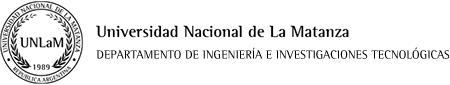](https://ingenieria.unlam.edu.ar/)  
[by-nc-sa_80x15.png](https://creativecommons.org/licenses/by-sa/4.0/deed.es_ES) 
2025 [Víctor A. Bettachini](mailto:vbettachini@unlam.edu.ar)  

---

> ## 🎯 Objetivos
>
> Al completar esta clase, el estudiante podrá:
>
> 1. **Definir los ángulos de Euler** ($\varphi, \theta, \psi$) como las coordenadas generalizadas necesarias para describir la orientación de un cuerpo rígido en el espacio.
> 2. **Relacionar la velocidad angular** ($\vec{\Omega}$) con las derivadas temporales de los ángulos de Euler mediante proyecciones geométricas en los ejes del cuerpo.
> 3. **Formular la energía cinética de rotación** utilizando los momentos principales de inercia en un sistema de ejes donde el tensor de inercia es diagonal.
> 4. **Aplicar el formalismo de Euler-Lagrange** para deducir las ecuaciones dinámicas de la rotación, utilizando la regla de la cadena para conectar velocidades angulares y coordenadas generalizadas.
> 5. **Obtener las Ecuaciones de Euler** en su forma canónica, integrando la inercia del cuerpo con los torques externos aplicados.
>
---
> ## 📚 Prerrequisitos
>
> Para aprovechar este cuaderno se asume que el estudiante conoce:
>
> #### Matemática
> - **Geometría y Trigonometría**: proyecciones vectoriales en 3D y rotaciones de sistemas de coordenadas.
> - **Cálculo multivariable**: uso extensivo de la regla de la cadena para derivadas parciales y totales.
>
> #### Física
> - **Tensor de inercia**: haber completado las lecciones sobre el cálculo y la diagonalización del tensor de inercia.
> - **Cinemática rotacional**: conceptos de velocidad angular, ejes principales y momentos de inercia.
> - **Mecánica Lagrangiana**: fluidez en el planteo del Lagrangiano ($L = T - V$) y las ecuaciones de Euler-Lagrange.
>
> #### Programación / Herramientas
> - **SymPy Mechanics**: manejo de marcos de referencia (`ReferenceFrame`), matrices simbólicas y el método `derive_by_array`.
> - **Automatización**: experiencia previa con las funciones de cálculo de energías y ecuaciones de movimiento desarrolladas en el curso.
---

In [1]:
# biblioteca de cálculo simbólico
import sympy as sm
import sympy.physics.mechanics as me
me.init_vprinting() # notación con puntos para derivadas temporales

## Convención de ángulos para la rotación de un cuerpo rígido
>**Referencia**:
>- $\S$ 35 "Ángulos de Euler". Landau y Lifschitz. Mecánica. 2.a ed. Reverté  
>- Sección 12.7 "Ángulos de Euler". Jerry B. Marion. Dinámica clásica de las partículas y sistemas. 2.a ed. Reverté

Como se vió al trabajar con el **tensor de inercia**, es útil orientar un sistema de referencia con ejes particulares de un cuerpo rígido.
Si $x_1, x_2, x_3$ son los ejes para este referencia móvil, es usual seguir la convención de expresar las rotaciones del sistema de referencia usando los **ángulos de Euler** para llevar de un sistema fijo $X, Y, Z$ a $x_1, x_2, x_3$.

**Primer paso**: Mover desde $X$ hasta el eje nodal $N$  
Aplicando la velocidad angular $\dot{\varphi}$ en el eje $Z$ se logra una rotación con un ángulo $\varphi$.
Esto dejaría $x_1$ colineal con $N$.

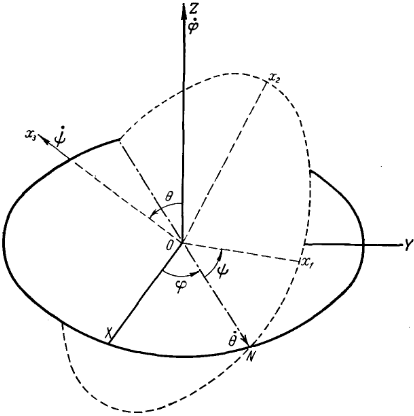

**Segundo paso**: Levantar $x_2$ del plano $XY$.    
Aplicar $\dot{\theta}$ en la dirección de $\overline{O N}$ causa que $x_3$ se separe de $Z$ con un ángulo $\theta$.

**Tercer paso**: Levantar $x_1$ del plano $XY$.    
Aplicar $\dot{\psi}$ en la dirección de $x_3$ causa que $x_1$ se separe de $N$ con un ángulo $\psi$.

Los $\varphi, \theta, \psi$ son los **ángulos de Euler** y serán las coordenadas generalizadas utilizadas para describir cualquier rotación desde el sistema fijo $X, Y, Z$.

In [2]:
# ángulos de Euler
fi, zeta, psi =  sm.symbols(r'\varphi \theta \psi')
fi, zeta, psi

## Euler-Lagrange para la rotación

>**Referencia**:
>- $\S$ 36 "Ecuaciones de Euler". Landau y Lifschitz. Mecánica. 2.a ed. Reverté  
>- Sección 12.8 "Ecuaciones de Euler para un cuerpo rígido". Jerry B. Marion. Dinámica clásica de las partículas y sistemas. 2.a ed. Reverté

### Energía cinética de rotación

Los ejes $x_1, x_2, x_3$ se pueden alinear con el cuerpo para que el tensor de inercial $\overline{\overline{I}}$ sea diagonal.
Los elementos de esta diagonal son los **momentos principales de inercia** de este cuerpo, $I_{i}$,  y los $x_i$ son sus **ejes principales de inercia**.
En tal caso la energía cinética de rotación del cuerpo se expresa como:

$$
T_\text{rot} = \frac{1}{2} \left( I_1 \Omega_1^2 + I_2 \Omega_2^2 + I_3 \Omega_3^2 \right)
,
$$
donde $\Omega_1, \Omega_2, \Omega_3$ son las componentes de la **velocidad angular** del cuerpo en cada uno de los ejes $x_1, x_2, x_3$.

### Euler-Lagrange en coordenadas generalizadas para la rotación

Para la rotación las ecuaciones de Euler-Lagrange
$$
\begin{aligned}
\frac{\mathrm{d}}{\mathrm{d} t} \frac{\partial \mathcal{L} }{\partial \dot{q}_i }
& -\frac{\partial \mathcal{L} }{\partial q_i}
 = 0
\end{aligned},
$$
deben expresarse en términos de las coordenadas generalizadas $\varphi, \theta, \psi$ y sus velocidades $\dot{\varphi}, \dot{\theta}, \dot{\psi}$.

Si el cuerpo no está afectado por un campo externo, no hay energía potencial $V$, y por tanto el Lagrangiano $\mathcal{L}$ se reduce a la energía cinética de rotación, es decir $\mathcal{L} = T_\text{rot}$.

Pero como elegimos como coordenadas generalizas $\varphi, \theta, \psi$, la ecuación de Euler-Lagrange debe expresarse en función de las mismas y sus correspondientes velocidades generalizadas.
Por ejemplo para $\psi$ la ecuación sería:
$$
\frac{d}{d t} \frac{\partial T_\text{rot}}{\partial \dot{\psi}}
- \frac{\partial T_\text{rot}}{\partial \psi} 
= 0
,
$$
algo que debemos compatibilizar con la expresión que tenemos de $T_\text{rot}$ en función de $\Omega_1, \Omega_2, \Omega_3$.

Para esto basta con utilizar la regla de la cadena:

$$
\frac{d}{d t} \sum_i \frac{\partial T_\text{rot}}{\partial \Omega_i} \frac{\partial \Omega_i}{\partial \dot{\psi}} 
- \sum_i \frac{\partial T_\text{rot}}{\partial \Omega_i} \frac{\partial \Omega_i}{\partial \psi}
= 0
,
$$
pero esto nos obliga a obtener las componentes de la velocidad angular $\Omega_i$ en función de las velocidades generalizadas $\dot{\varphi}, \dot{\theta}, \dot{\psi}$.


### Velocidad angular en función de las velocidades generalizadas

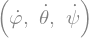

In [3]:
# velocidades angulares a proyectar
fi_punto, zeta_punto, psi_punto =  sm.symbols(r'\dot{\varphi} \dot{\theta} \dot{\psi}')
fi_punto, zeta_punto, psi_punto

Obtener las proyecciones en los ejes $x_i$ de las $\dot{\theta}, \dot{\varphi}, \dot{\psi}$ que se mostraron en la figura es un problema de geometría.
Es conveniente volver a tener presente la figura.

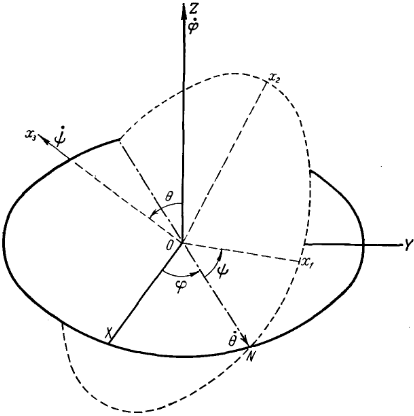

**Proyección sobre $x_3$**
- $\dot{\psi}$ coincide con $x_3$ por lo que tiene proyección $1$.
- $\dot{\varphi}$ está separado en $\theta$ de $x_3$ por lo que proyecta como $\cos \theta$.
- Entonces $\Omega_3 = \dot{\psi} + \dot{\varphi} \cos \theta$.

**Proyección sobre $x_1$**
- $\dot{\theta}$ está separado en $\psi$ de $x_1$ por lo que proyecta como $\cos \psi$.
- Si $\theta = \frac{\pi}{2}$ y $\psi = \frac{\pi}{2}$, coincidiría $\dot{\varphi}$ con $x_1$, así que su proyección va con $\sin \theta \sin \psi$.
- Entonces $\Omega_1 = \dot{\theta} \cos \psi + \dot{\varphi} \sin \theta \sin \psi$.

**Proyección sobre $x_2$**
- Si $\psi = \frac{\pi}{2}$ la proyección de $\dot{\theta}$ se opone a $x_2$, así que su proyección es $-\sin \psi$.
- Si $\theta = \frac{\pi}{2}$ y $\psi = 0$, concidirá $\dot{\varphi}$ con $x_2$, así que su proyección es $\sin \theta \cos \psi$.
- Entonces $\Omega_2 = -\dot{\theta} \sin \psi + \dot{\varphi} \sin \theta \cos \psi$.

Lo anterior se resume en el vector de velocidades angulares:
<!--
$$
\boxed{
\vec{\Omega} = 
\begin{pmatrix}
\Omega_1\\
\Omega_2\\
\Omega_3\\
\end{pmatrix}
= 
\begin{pmatrix}
\dot{\varphi} \sin{\theta} \sin{\psi} + \dot{\theta} \cos{\psi} \\
\dot{\varphi} \sin{\theta} \cos{\psi} - \dot{\theta} \sin{\psi} \\
\dot{\varphi} \cos{\theta} + \dot{\psi}
\end{pmatrix}
}
$$
-->

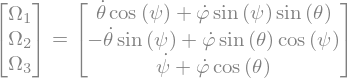

In [11]:
omega1 = sm.Eq(sm.Symbol('Omega_1'), zeta_punto * sm.cos(psi) + fi_punto * sm.sin(zeta)* sm.sin(psi))
omega2 = sm.Eq(sm.Symbol('Omega_2'), - zeta_punto * sm.sin(psi) + fi_punto * sm.sin(zeta) * sm.cos(psi))
omega3 = sm.Eq(sm.Symbol('Omega_3'), sm.cos(zeta)* fi_punto + psi_punto)

omega = sm.Eq(
  sm.Matrix([omega1.lhs, omega2.lhs, omega3.lhs]),
  sm.Matrix([omega1.rhs, omega2.rhs, omega3.rhs]),
)
omega

### Forma canónica de las ecuaciones de Euler-Lagrange para la rotación

#### Coordenada $\psi$

Retomamos el cálculo de las ecuaciones de Euler-Lagrange, empezando por la que corresponde a la coordenada $\psi$:
$$
\frac{d}{d t} \sum_i \frac{\partial T_\text{rot}}{\partial \Omega_i} \frac{\partial \Omega_i}{\partial \dot{\psi}} 
- \sum_i \frac{\partial T_\text{rot}}{\partial \Omega_i} \frac{\partial \Omega_i}{\partial \psi}
= 0
$$

Los $\dfrac{\partial \Omega_i}{\partial \psi}$ son

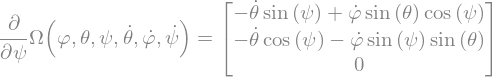

In [5]:
omegaPseudovector = sm.Function('Omega')(fi, zeta, psi, zeta_punto, fi_punto, psi_punto)
variable_derivación = psi
sm.Eq(
  sm.Derivative(omegaPseudovector, variable_derivación),
  sm.derive_by_array(omega.rhs, variable_derivación)
)

No es difícil darse cuenta que componentes de esta derivada del pseudovector se corresponden con otras componentes del mismo pseudovector. 
$$
\left\{
  \begin{aligned}
    \frac{\partial \Omega_1}{\partial \psi} 
    &= 
    \dot{\varphi} \sin{\theta} \cos{\psi} - \dot{\theta} \sin{\psi} = \Omega_2\\
    \frac{\partial \Omega_2}{\partial \psi} 
    &= 
    - \dot{\varphi} \sin{\theta} \sin{\psi} - \dot{\theta} \cos{\psi} = - \Omega_1\\
    \frac{\partial \Omega_3}{\partial \psi} 
    &= 0 \\
  \end{aligned}
\right.
$$

Ahora analicemos las derivadas del pseudovector con la velocidad generalizada $\dot{\psi}$.
Estas $\dfrac{\partial \Omega_i}{\partial \dot{\psi}}$ son 

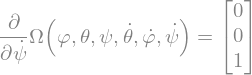

In [6]:
variable_derivación = psi_punto
sm.Eq(
  sm.Derivative(omegaPseudovector, variable_derivación),
  sm.derive_by_array(omega.rhs, variable_derivación)
)

Es decir, que solo hay dependencia con $\dot{\psi}$ en la tercera componente del pseudovector de velocidades angulares, $\Omega_3$.
$$
\left\{
  \begin{aligned}
    \frac{\partial \Omega_1}{\partial {\dot{\psi}} } 
    &= \frac{\partial \Omega_2}{\partial {\dot{\psi}}  } 
    = 0 \\ 
    \frac{\partial \Omega_3}{\partial {\dot{\psi}} } 
    &= 1 \\
  \end{aligned}
\right.
$$

Y como los $\dfrac{\partial T_\text{rot}}{\partial \Omega_i} = I_i \Omega_i$ queda

$$
\frac{d}{d t} \left( I_3 \Omega_3 \right) 
- \left[ I_1 \Omega_1 \Omega_2 + I_2 \Omega_2 (-\Omega_1) \right]
= 
I_3 \dot{\Omega}_3
- (I_1 - I_2) \Omega_1 \Omega_2
 = 0
$$

#### Coordenada $\theta$
Siguiendo el mismo procedimiento con $\theta$ y $\varphi$ se obtienen las otras dos ecuaciones de Euler-Lagrange.

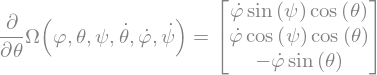

In [7]:
variable_derivación = zeta
sm.Eq(
  sm.Derivative(omegaPseudovector, variable_derivación),
  sm.derive_by_array(omega.rhs, variable_derivación)
)

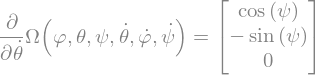

In [8]:
variable_derivación = zeta_punto
sm.Eq(
  sm.Derivative(omegaPseudovector, variable_derivación),
  sm.derive_by_array(omega.rhs, variable_derivación)
)

$$
\frac{d}{d t} \sum_i \frac{\partial T_\text{rot}}{\partial \Omega_i} \frac{\partial \Omega_i}{\partial \dot{\theta}} 
- \sum_i \frac{\partial T_\text{rot}}{\partial \Omega_i} \frac{\partial \Omega_i}{\partial \theta}
= 0
$$

#### Las tres ecuaciones de Euler-Lagrange para la rotación tienen la misma forma

Antes de resumir todas estas ecuaciones recordemos que el momento de inercia $\vec{L} = \overline{\overline{I}} \vec{\Omega}$ puede descomponerse en aquellos asociados a cada $x_i$, es decir $L_i$.
Cada uno de estos puede estar afectado por algún torque externo $\vec{\tau}$ que hay que descomponer en $\tau_i$ en cada $x_i$.
Estos los tratamos igual que a cualquier otra fuerza generalizada externa $Q_i$:

$$
\frac{\mathrm{d}}{\mathrm{d} t} \frac{\partial}{\partial \dot{q_i}} \mathcal{L}  
- \frac{\partial}{\partial q_i} \mathcal{L} 
= Q_i
,
$$
para el caso de la rotación se puede resumir en

$$
\boxed{
I_i \dot{\Omega}_i
- (I_j - I_k) \Omega_j \Omega_k 
= \tau_i 
},
$$
que resulta en un sistema que debe resolverse en conjunto:

$$
\left\{
  \begin{aligned}
  I_1 \dot{\Omega}_1
  - (I_2 - I_3) \Omega_2 \Omega_3 
  &= \tau_1\\
  I_2 \dot{\Omega}_2
  - (I_3 - I_1) \Omega_3 \Omega_1
  &= \tau_2\\
  I_3 \dot{\Omega}_3
  -(I_1 - I_2) \Omega_1 \Omega_2
  &= \tau_3
  \end{aligned}
\right.
$$

Estas ecuaciones arrojarán el mismo resultado que si se hubiera resuelto el problema con las ecuaciones de Euler-Lagrange homogéna agregando los términos de fuerzas generalizadas, que en este caso son torques.
La elección de un método u otro dependerá de la complejidad del problema y de la facilidad para identificar las fuerzas generalizadas.

### Versión compacta

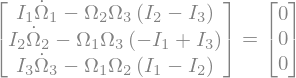

In [12]:
# Marco de referencia
e = me.ReferenceFrame('e')

# Velocidad angular
omega_1, omega_2, omega_3 = sm.symbols('Omega_1 Omega_2 Omega_3')
velocidad_angular = omega_1 * e.x + omega_2 * e.y + omega_3 * e.z # la terna x,y,z en los ejes propios son 1,2,3

# Acelación angular
omega_punto_1, omega_punto_2, omega_punto_3 = sm.symbols(r'\dot{\Omega}_1 \dot{\Omega}_2 \dot{\Omega}_3')
aceleracion_angular = omega_punto_1 * e.x + omega_punto_2 * e.y + omega_punto_3 * e.z

# Momentos de inercia
I_1, I_2, I_3 = sm.symbols('I_1 I_2 I_3')

# Ecuaciones homogéneas de Euler de la rotación
el_rotación_homogenea = \
  (I_1 * omega_punto_1 - (I_2 - I_3) * omega_2 * omega_3 )* e.x + \
  (I_2 * omega_punto_2 - (I_3 - I_1) * omega_3 * omega_1 )* e.y + \
  (I_3 * omega_punto_3 - (I_1 - I_2) * omega_1 * omega_2 )* e.z

sm.Eq(
  el_rotación_homogenea.to_matrix(e),
  (0* e.x + 0* e.y + 0 * e.z).to_matrix(e)
)

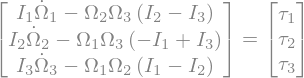

In [10]:
# Torque
tau_1, tau_2, tau_3 = sm.symbols('tau_1 tau_2 tau_3')
torque = tau_1 * e.x + tau_2 * e.y + tau_3 * e.z

el_rotación = sm.Eq(
  el_rotación_homogenea.to_matrix(e),
  torque.to_matrix(e)
)
el_rotación